# Exploring the effect of Remote Work on Salary

## 1. Business Understanding

To be revisited...

## 2. Data Understanding — Exploratory Data Analysis

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

# url = 'https://github.com/StackExchange/Survey/blob/main/packages/archive/2025/results.csv?raw=true'

path = './data/data.csv'

df = pd.read_csv(path, low_memory=False)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 64.6 MB


In [42]:
df.shape

(49191, 172)

In [43]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


### Feature Selection

In [44]:
# Narrowing the dataset to the two features of importance, plus the ResponseId column to keep track of the respondents. 
# I will also make a copy of the dataframe to avoid any SettingWithCopyWarning errors.

cols = ['RemoteWork', 'ConvertedCompYearly']
data = df[cols].copy()

print(data.shape)
data.head()

(49191, 2)


,RemoteWork,ConvertedCompYearly
0,Remote,61256.0
1,"Hybrid (some in-person, leans heavy to flexibi...",104413.0
2,NaN,53061.0
3,Remote,36197.0
4,NaN,60000.0


In [45]:
data.isnull().sum()

RemoteWork             15411
ConvertedCompYearly    25244
dtype: int64

### Salary Distribution

In [46]:
data["ConvertedCompYearly"].describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

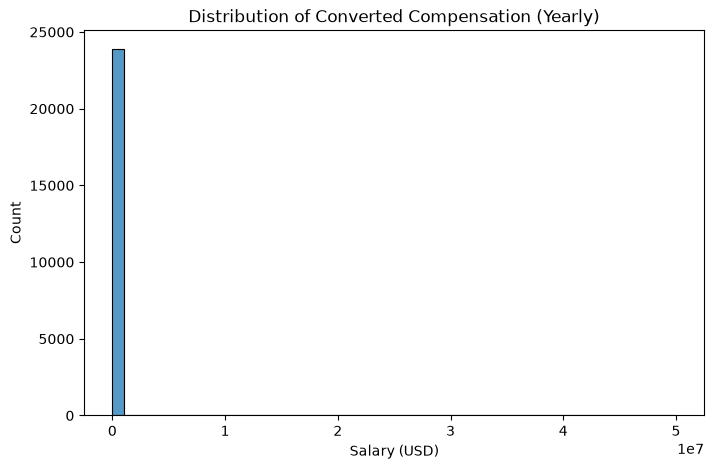

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(data['ConvertedCompYearly'].dropna(), bins=50)
plt.title('Distribution of Converted Compensation (Yearly)')
plt.xlabel('Salary (USD)')
plt.show()

#### Observations

The distribution of `ConvertedCompYearly` is highly right-skewed, with a long tail of extreme high values. Most entries cluster at lower salary values, while a small number of outliers pull the mean well above the median. This skew would distort any model that assumes normally distributed errors (like linear regression), so I applied a log transformation to `ConvertedCompYearly` to aid proper visualization and further analysis.

### Log transformation of `ConvertedCompYearly`

In [48]:
data['LogSalary'] = np.log1p(data['ConvertedCompYearly'])


In [49]:
data["LogSalary"].describe()

count    23947.000000
mean        10.847896
std          1.570676
min          0.693147
25%         10.549858
50%         11.229514
75%         11.700210
max         17.727534
Name: LogSalary, dtype: float64

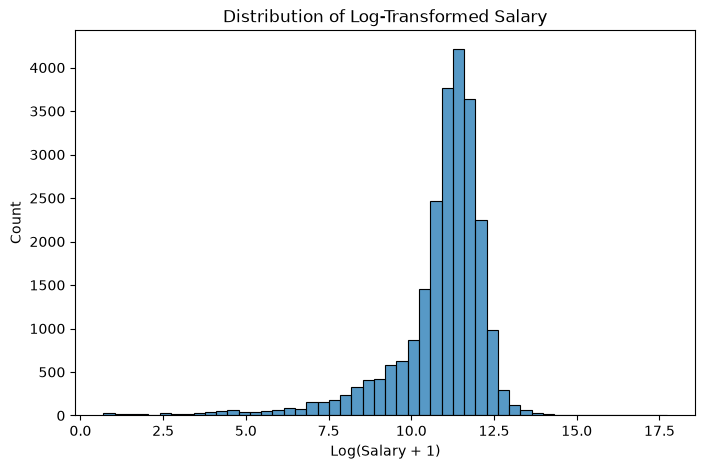

In [50]:

# Plotting `LogSalary` distribution

plt.figure(figsize=(8,5))
sns.histplot(data['LogSalary'].dropna(), bins=50)
plt.title('Distribution of Log-Transformed Salary')
plt.xlabel('Log(Salary + 1)')
plt.show()

### `RemoteWork` Value Counts

In [51]:
data['RemoteWork'].value_counts(dropna=False)

RemoteWork
NaN                                                                             15411
Remote                                                                          10931
Hybrid (some remote, leans heavy to in-person)                                   6732
In-person                                                                        6042
Hybrid (some in-person, leans heavy to flexibility)                              5831
Your choice (very flexible, you can come in when you want or just as needed)     4244
Name: count, dtype: int64

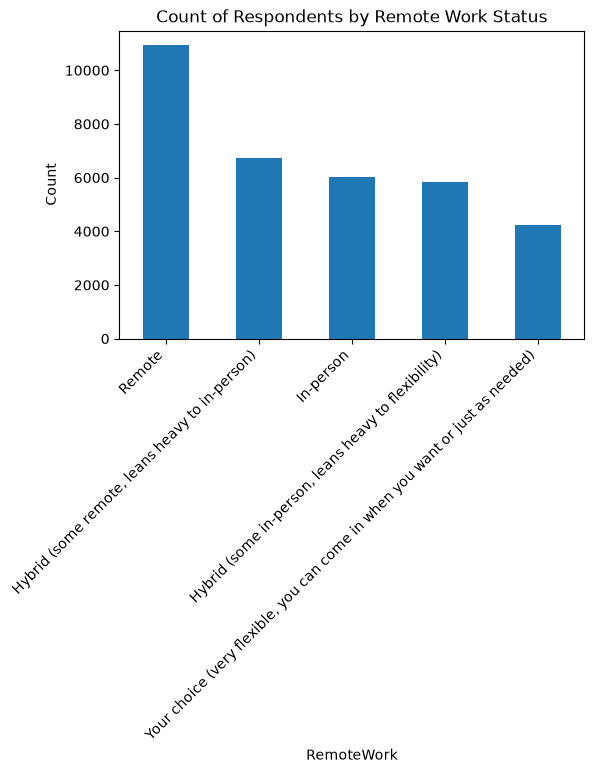

In [52]:
plt.figure(figsize=(6,4))
data['RemoteWork'].value_counts().plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.title('Count of Respondents by Remote Work Status')
plt.ylabel('Count')
plt.show()

### `LogSalary` v. `RemoteWork` Analysis

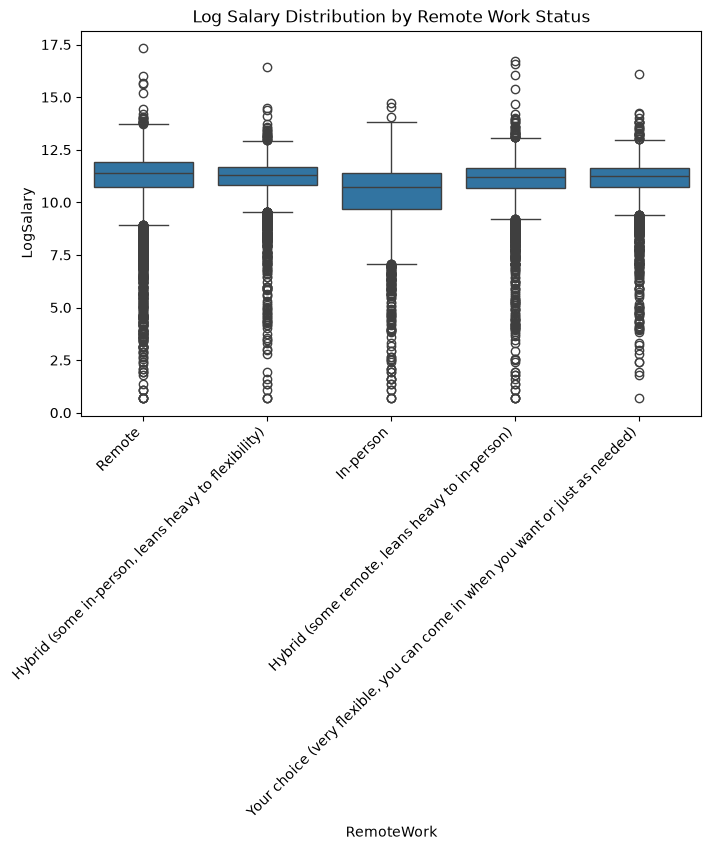

In [53]:
# LogSalary is used in place of ConvertedCompYearly to normalize the distribution and make it easier to visualize and analyze the trends between both.

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='RemoteWork', y='LogSalary')
plt.title('Log Salary Distribution by Remote Work Status')
plt.xticks(rotation=45, ha='right')
plt.show()

### Summary Statistics By Group

In [54]:
data.groupby('RemoteWork')['LogSalary'].describe()

,count,mean,std,min,25%,50%,75%,max
RemoteWork,,,,,,,,
"Hybrid (some in-person, leans heavy to flexibility)",3815.0,11.052481,1.223528,0.693147,10.816090,11.301797,11.661483,16.448964
"Hybrid (some remote, leans heavy to in-person)",4203.0,10.929946,1.394031,0.693147,10.668711,11.197653,11.649862,16.727184
In-person,3199.0,10.367142,1.654672,0.693147,9.680250,10.745206,11.415821,14.731802
Remote,7126.0,11.008766,1.566909,0.693147,10.720968,11.390679,11.918397,17.328628
"Your choice (very flexible, you can come in when you want or just as needed)",2753.0,10.955572,1.346934,0.693147,10.744925,11.230708,11.633008,16.118096


### Summary of Exploratory Findings

After narrowing the dataset to `RemoteWork` and `ConvertedCompYearly`, I found substantial missingness: 15,411 missing values in RemoteWork and 25,244 missing values in `ConvertedCompYearly`. I also observed extreme outliers in `ConvertedCompYearly`, along with severe right skew. To make the data usable for visualization and modeling, I applied a log transformation (log1p) to `ConvertedCompYearly`, which produced a more interpretable, roughly normal distribution.

`RemoteWork` comprises five categories. The majority of entries were fully Remote (10,931), followed by two Hybrid variants (6,732 leaning in-person, 5,831 leaning flexible), In-person (6,042), and a smaller "your choice" flexible category (4,244). 

The boxplot of log-transformed salary by remote work status shows that In-person workers have a visibly lower median salary than the other four categories, which cluster closely together. However, all `RemoteWork` categories show a large number of low-end outliers. This suggests the data may contain unrealistic or low-quality salary entries (e.g. near-zero values, part-time or student respondents) that should be filtered out during data preparation, in addition to the high-end outliers already noted.

Given the missingness and outliers, the data clearly requires cleaning before modeling. Next, I will: (1) drop rows missing RemoteWork and/or `ConvertedCompYearly`, and (2) address the remaining outliers in the salary data.

## 3. Data Preparation

### Dropping Null Values

In [55]:
# Dropping null values from the dataset to ensure that the analysis is based on complete cases only. 
# This is to avoid any biases or inaccuracies in the results.

before_outlier_removal = data.shape[0]
data = data.dropna()

### Applying Quantile-based Outlier Filtering

In [56]:
Q1 = data['LogSalary'].quantile(0.25) # First quartile
Q3 = data['LogSalary'].quantile(0.75) # Third quartile
IQR = Q3 - Q1 # Interquartile range

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data["LogSalary"] >= lower_bound) & (data["LogSalary"] <= upper_bound)] # This is the subset of data we want to keep
after_outlier_removal = len(data)

In [57]:
data.shape
print(f"Rows before: {before_outlier_removal}, Rows after: {after_outlier_removal}, Removed: {before_outlier_removal - after_outlier_removal}")

Rows before: 49191, Rows after: 19246, Removed: 29945


In [58]:
data.head()

,RemoteWork,ConvertedCompYearly,LogSalary
0,Remote,61256.0,11.022833
1,"Hybrid (some in-person, leans heavy to flexibi...",104413.0,11.556119
3,Remote,36197.0,10.496759
7,Remote,72000.0,11.184435
8,Remote,70000.0,11.156265


In [59]:
# Recomputing the descriptive statistics for LogSalary after removing outliers to see how the distribution has changed.

data["LogSalary"].describe()

count    19246.000000
mean        11.227300
std          0.786484
min          8.927049
25%         10.793989
50%         11.304806
75%         11.756789
max         13.377007
Name: LogSalary, dtype: float64

In [60]:
data.groupby('RemoteWork')['LogSalary'].describe()

,count,mean,std,min,25%,50%,75%,max
RemoteWork,,,,,,,,
"Hybrid (some in-person, leans heavy to flexibility)",3615.0,11.253269,0.686353,8.930230,10.906286,11.318989,11.686593,13.304687
"Hybrid (some remote, leans heavy to in-person)",3892.0,11.198969,0.749967,8.929435,10.793989,11.248048,11.661483,13.366222
In-person,2709.0,10.888097,0.896399,8.927580,10.277152,10.958287,11.512935,13.345344
Remote,6478.0,11.373692,0.797075,8.927049,10.958818,11.476795,11.931642,13.377007
"Your choice (very flexible, you can come in when you want or just as needed)",2552.0,11.222191,0.704470,8.949755,10.862991,11.293643,11.661483,13.304687


In [61]:
# Reset the index of the data DataFrame

data = data.reset_index(drop=True)

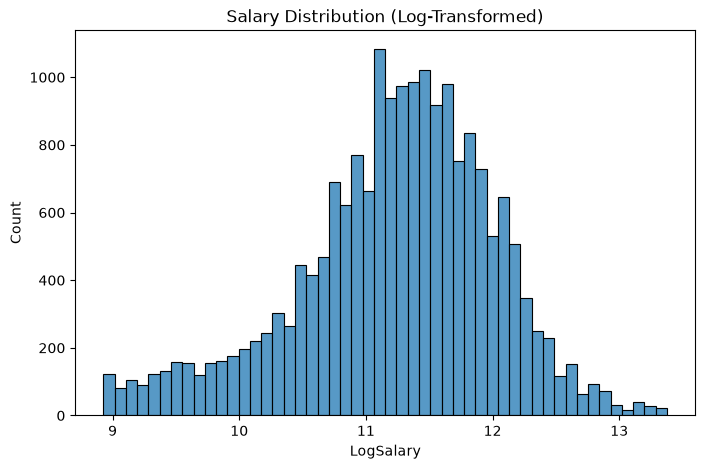

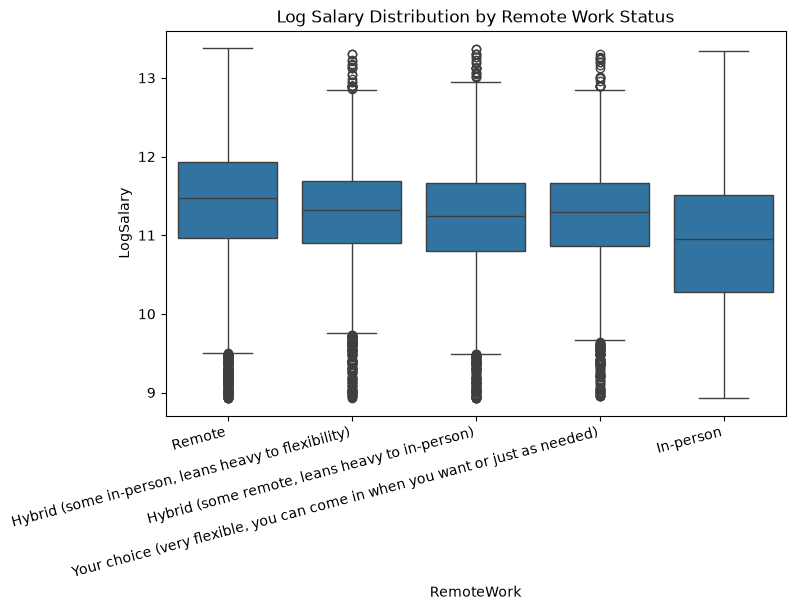

In [62]:
# Visualizing the distribution of LogSalary after removing outliers

plt.figure(figsize=(8,5))
sns.histplot(data['LogSalary'], bins=50)
plt.title('Salary Distribution (Log-Transformed)')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='RemoteWork', y='LogSalary')
plt.title('Log Salary Distribution by Remote Work Status')
plt.xticks(rotation=15, ha='right')
plt.show()

### Summary

I dropped rows with missing values in `RemoteWork` or `ConvertedCompYearly`, since these are the two core variables needed to answer the research question. Keeping rows with missing values in either column would introduce noise and bias into the analysis.

After transforming the target, I applied an IQR-based outlier filter to LogSalary. This method identifies the middle 50% of the data (between the 25th and 75th percentiles) and flags anything more than 1.5 times that range beyond either boundary as an outlier. I chose this approach over a fixed dollar threshold because it adapts to the spread of the data rather than relying on an arbitrary cutoff. This filter removed 1,850 rows (from 21,096 to 19,246, a reduction of 8.8%), eliminating extreme low and high salary values while preserving the core distribution.

After removing outliers, I re-plotted the distribution and boxplots and saw a clear improvement: the cloud of extreme low-end points from the original boxplots was now gone, and the salary distribution by RemoteWork category became much easier to read and compare across groups.

With missing values dropped, the target variable log-transformed, and outliers filtered, the dataset is now ready for modeling.

## 4. Feature Engineering & Modelling

### Train-Test Split

In [63]:
X_raw = data[['RemoteWork']]
y = data['LogSalary']


X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

X_train_raw
print(X_train_raw.shape, X_test_raw.shape)

(15396, 1) (3850, 1)


### One-Hot Encoding `RemoteWork`

In [64]:
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

X_train = encoder.fit_transform(X_train_raw)
X_test = encoder.transform(X_test_raw)

feature_names = encoder.get_feature_names_out(X_train_raw.columns)
print(feature_names)

['RemoteWork_Hybrid (some remote, leans heavy to in-person)'
 'RemoteWork_In-person' 'RemoteWork_Remote'
 'RemoteWork_Your choice (very flexible, you can come in when you want or just as needed)']


In [65]:
rename_map = {
    'RemoteWork_Hybrid (some remote, leans heavy to in-person)': 'Hybrid_LeansInPerson',
    'RemoteWork_In-person': 'InPerson',
    'RemoteWork_Remote': 'Remote',
    'RemoteWork_Your choice (very flexible, you can come in when you want or just as needed)': 'FlexibleChoice'
}

feature_names_clean = [rename_map.get(f, f) for f in feature_names]

X_train = pd.DataFrame(X_train, columns=feature_names_clean, index=X_train_raw.index)
X_test = pd.DataFrame(X_test, columns=feature_names_clean, index=X_test_raw.index)

In [66]:
X_train.head()
X_test.head()

,Hybrid_LeansInPerson,InPerson,Remote,FlexibleChoice
4318,1.0,0.0,0.0,0.0
2117,1.0,0.0,0.0,0.0
4999,0.0,0.0,1.0,0.0
17212,0.0,0.0,1.0,0.0
1162,0.0,0.0,0.0,1.0


**Baseline Category: Hybrid(some in-person, leans heavily to flexibility)**

### Selecting a Model

Since the target variable, `LogSalary`, is a continuous variable, this is a regression problem. I chose Linear Regression because my only predictor, `RemoteWork`, is a single categorical feature: linear regression's coefficients directly quantify how much each remote work category shifts salary relative to a baseline category, which directly speaks to my research question. 

More complex models (e.g. Random Forest) could technically be applied, but with just one categorical predictor, they would add complexity without meaningfully improving predictive power or interpretability. Linear Regression offers a good balance of both.

### Modelling Training & Prediction

In [67]:
model = LinearRegression()
model.fit(X_train, y_train)

model.coef_

array([-0.0644694 , -0.37753652,  0.11055146, -0.03093126])

In [68]:
coef_dict = {name: round(float(coef), 4) for name, coef in zip(feature_names_clean, model.coef_)}
print(f"Coefficients: {coef_dict}")
print(f"Intercept: {round(model.intercept_, 4)}")

Coefficients: {'Hybrid_LeansInPerson': -0.0645, 'InPerson': -0.3775, 'Remote': 0.1106, 'FlexibleChoice': -0.0309}
Intercept: 11.2604


In [69]:
y_pred =model.predict(X_test)

## 5. Evaluations

Evaluations will be made using R2, Mean Absolute Error and Root Mean Squared Error.

In [70]:
r2_score = r2_score(y_test, y_pred)
mean_absolute_error = mean_absolute_error(y_test, y_pred)
root_mean_squared_error =  np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score: {r2_score}")
print(f"Mean Absolute Error: {mean_absolute_error}")
print(f"Root Mean Squared Error: {root_mean_squared_error}")

R2 Score: 0.03634385883698388
Mean Absolute Error: 0.5945352060290531
Root Mean Squared Error: 0.7697620299359423


### Interpreting the Coefficients

The model's intercept (11.26) represents the baseline predicted log-salary for the reference category, `Hybrid (some in-person, leans heavy to flexibility)`. The coefficients for the remaining categories show how much each shifts predicted log-salary relative to that baseline:

- **Remote (+0.111):** Fully remote workers are predicted to earn more than the baseline hybrid group.
- **Hybrid, leans in-person (-0.065):** Slightly lower predicted salary than the baseline.
- **Flexible choice (-0.031):** Nearly identical to the baseline, with a very slight decrease.
- **In-person (-0.378):** The largest effect in the model; fully in-person workers are predicted to earn substantially less than every other category.

Converting the intercept and coefficients back from log scale shows this pattern in real dollar terms:

In [71]:
# Converting the intercept and coefficients back from log scale

baseline_salary = np.expm1(model.intercept_)
hybrid_leans_in_person_salary = np.expm1(model.intercept_ + model.coef_[0])
in_person_salary = np.expm1(model.intercept_ + model.coef_[1])
remote_salary = np.expm1(model.intercept_ + model.coef_[2])
flexible_choice_salary = np.expm1(model.intercept_ + model.coef_[3])

print(f"Baseline Salary: ${baseline_salary:.2f}")
print(f"Hybrid, Leans In-Person Salary: ${hybrid_leans_in_person_salary:.2f}")
print(f"Flexible Choice Salary: ${flexible_choice_salary:.2f}")
print(f"In-person Salary:  ${in_person_salary:.2f}")

Baseline Salary: $77683.85
Hybrid, Leans In-Person Salary: $72833.58
Flexible Choice Salary: $75317.74
In-person Salary:  $53255.70


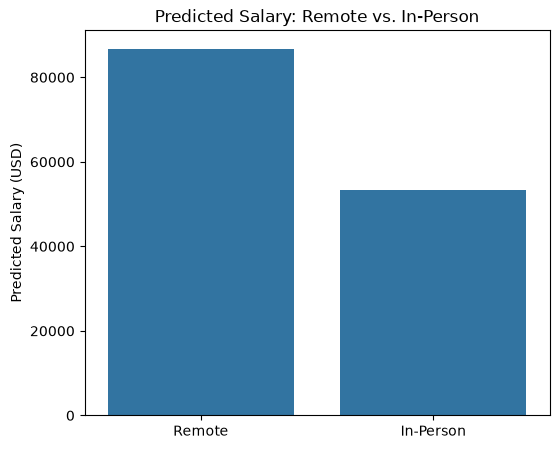

In [ ]:
# Plotting predicted results (Remote vs. In-person)

plt.figure(figsize=(6,5))
categories_1 = ['Remote', 'In-Person']
salaries_1 = [remote_salary, in_person_salary]

sns.barplot(x=categories_1, y=salaries_1)
plt.title('Predicted Salary: Remote vs. In-Person')
plt.ylabel('Predicted Salary (USD)')
plt.savefig('fig1_remote_vs_inperson.png', dpi=300, bbox_inches='tight')
plt.show()

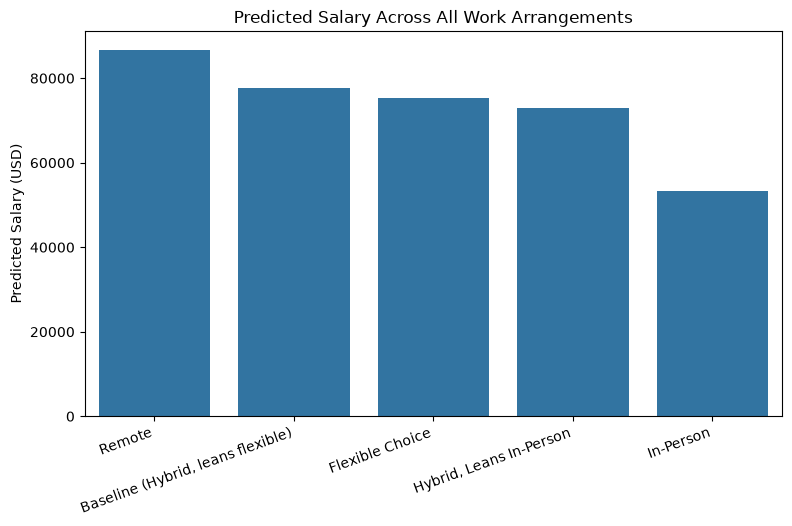

In [ ]:
# Plotting predicted results across all work arrangements

plt.figure(figsize=(9,5))
categories_2 = ['Remote', 'Baseline (Hybrid, leans flexible)', 'Flexible Choice', 'Hybrid, Leans In-Person', 'In-Person']
salaries_2 = [remote_salary, baseline_salary, flexible_choice_salary, hybrid_leans_in_person_salary, in_person_salary]

sns.barplot(x=categories_2, y=salaries_2)
plt.title('Predicted Salary Across All Work Arrangements')
plt.ylabel('Predicted Salary (USD)')
plt.xticks(rotation=20, ha='right')
plt.savefig('fig2_all_categories.png', dpi=300, bbox_inches='tight')
plt.show()

Compared to the baseline hybrid group ($77,684), fully in-person workers show the largest predicted salary gap, earning roughly $24,428 less. The other hybrid/flexible variants show smaller gaps below baseline ($2,366–$4,850 less), while fully remote workers are the only group predicted to earn more than baseline.

### Evaluating Model Performance

To assess how well the model performs, I used three standard regression metrics:

**R² (0.036):** This measures how much of the variation in salary is explained by remote work status alone. An **R²** of **0.036** means only about 3.6% of salary variation is explained by this one variable and the vast majority (the other ~96%) of what determines someone's lies outside factors included in this model.

**Mean Absolute Error (0.595) and Root Mean Squared Error (0.770):** Both measured on the log-salary scale, these indicate the model's predictions are, on average, off by a meaningful margin. RMSE, however penalizes large errors more heavily. The gap between MAE and RMSE (RMSE being higher) suggests a handful of larger prediction errors remain even after outlier removal.

### What This Tells Us

Together, these results show that remote work status does have a measurable relationship with salary, particularly considering the clear salary gap for in-person workers. However, this single variable is far from sufficient to predict salary on its own. Conclusively, we can establish that while remote work status is one contributing factor among many, it is not the primary driver of developer compensation.